# 04 Association Rule Mining

**Assignment 2: Explainable Maternal Health Risk Prediction** · KQC7016 Data Analytics

Classification tells us *which* class a patient is in; association rule mining (ARM) tells
us *which vital-sign patterns co-occur with each risk level* in human-readable `IF → THEN`
form. This is our second analytics method and the rule base the explainability layer
(notebook 05) and SLM narrative (notebook 06) draw on.

ARM is unsupervised/descriptive, so it runs on the **full deduplicated set** (451 rows) —
no train/test split is needed. Continuous vitals are discretised into **clinically
justified bins** taken from published guidelines (not data-driven cut-points).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from mlxtend.frequent_patterns import apriori, association_rules

sns.set_theme(style="whitegrid", context="notebook")
PLOTS = Path("plots")
df = pd.read_csv("data/maternal_clean.csv")
print("rows:", df.shape[0])
df.head()

rows: 451


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,risk_encoded
0,25,130,80,15.0,98.0,86,high risk,2
1,35,140,90,13.0,98.0,70,high risk,2
2,29,90,70,8.0,100.0,80,high risk,2
3,30,140,85,7.0,98.0,70,high risk,2
4,35,120,60,6.1,98.0,76,low risk,0


## 1. Clinical discretisation

| Variable | Bins (cut points) | Source |
|---|---|---|
| SystolicBP | normal <120 · elevated 120–139 · high ≥140 | ACOG gest. HTN ≥140; AHA/ACC 2017 |
| DiastolicBP | normal <80 · elevated 80–89 · high ≥90 | ACOG gest. HTN ≥90; AHA/ACC 2017 |
| BS | normal <7.0 · high ≥7.0 mmol/L | WHO/ADA fasting glucose ≥7.0 = diabetes |
| BodyTemp | normal <100.4 · fever ≥100.4 °F | standard fever definition |
| Age | young <20 · adult 20–34 · older ≥35 | ACOG advanced maternal age ≥35 |

`HeartRate` is **excluded**: the clinical tachycardia cut-point (≥100 bpm) yields zero
cases here (data max = 90), so it carries no clinical-range variation for rule mining.

In [2]:
def bin_systolic(v):  return "SBP_high" if v >= 140 else ("SBP_elevated" if v >= 120 else "SBP_normal")
def bin_diastolic(v): return "DBP_high" if v >= 90 else ("DBP_elevated" if v >= 80 else "DBP_normal")
def bin_bs(v):        return "BS_high" if v >= 7.0 else "BS_normal"
def bin_temp(v):      return "Temp_fever" if v >= 100.4 else "Temp_normal"
def bin_age(v):       return "Age_older" if v >= 35 else ("Age_young" if v < 20 else "Age_adult")

disc = pd.DataFrame({
    "SystolicBP":  df["SystolicBP"].map(bin_systolic),
    "DiastolicBP": df["DiastolicBP"].map(bin_diastolic),
    "BS":          df["BS"].map(bin_bs),
    "BodyTemp":    df["BodyTemp"].map(bin_temp),
    "Age":         df["Age"].map(bin_age),
    "Risk":        "Risk_" + df["RiskLevel"].str.split().str[0],   # Risk_low/mid/high
})
disc.to_csv("data/maternal_discretized.csv", index=False)
for col in disc.columns:
    print(col, ":", dict(disc[col].value_counts()))

SystolicBP : {'SBP_elevated': 211, 'SBP_normal': 197, 'SBP_high': 43}
DiastolicBP : {'DBP_normal': 220, 'DBP_elevated': 119, 'DBP_high': 112}
BS : {'BS_high': 296, 'BS_normal': 155}
BodyTemp : {'Temp_normal': 371, 'Temp_fever': 80}
Age : {'Age_adult': 189, 'Age_older': 137, 'Age_young': 125}
Risk : {'Risk_low': 233, 'Risk_high': 112, 'Risk_mid': 106}


## 2. One-hot transactions & frequent itemsets

Each patient becomes a transaction (set of bin items). The bin labels are already unique
across variables (`SBP_*`, `DBP_*`, `BS_*`, `Temp_*`, `Age_*`, `Risk_*`), so we one-hot
encode without adding a column prefix. We mine frequent itemsets with Apriori at
`min_support = 0.03` (≈14 patients) — low enough to retain high-risk combinations, which
are rarer because high risk is only ~25% of the data.

In [3]:
onehot = pd.get_dummies(disc, prefix="", prefix_sep="")   # item names = bin labels
print("transaction matrix:", onehot.shape)
print("items:", list(onehot.columns))
freq = apriori(onehot, min_support=0.03, use_colnames=True)
freq["len"] = freq["itemsets"].apply(len)
print("frequent itemsets:", freq.shape[0])
freq.sort_values("support", ascending=False).head(10)

transaction matrix: (451, 16)
items: ['SBP_elevated', 'SBP_high', 'SBP_normal', 'DBP_elevated', 'DBP_high', 'DBP_normal', 'BS_high', 'BS_normal', 'Temp_fever', 'Temp_normal', 'Age_adult', 'Age_older', 'Age_young', 'Risk_high', 'Risk_low', 'Risk_mid']
frequent itemsets: 563


,support,itemsets,len
9,0.822616,(Temp_normal),1
6,0.656319,(BS_high),1
75,0.529933,"(BS_high, Temp_normal)",2
14,0.516630,(Risk_low),1
5,0.487805,(DBP_normal),1
98,0.472284,"(Risk_low, Temp_normal)",2
0,0.467849,(SBP_elevated),1
2,0.436807,(SBP_normal),1
10,0.419069,(Age_adult),1
22,0.414634,"(SBP_elevated, Temp_normal)",2


## 3. Rules pointing at a risk level

We generate rules at `confidence ≥ 0.5`, then keep those whose **consequent is exactly one
risk level** (`Risk_low/mid/high`) with an antecedent of only vital-sign items — i.e.
*vitals → risk* — and `lift > 1` (the pattern makes that risk level *more* likely than its
base rate). Rules are ranked by lift.

In [4]:
rules = association_rules(freq, metric="confidence", min_threshold=0.5)
risk_items = {"Risk_low", "Risk_mid", "Risk_high"}

def is_vitals_to_risk(row):
    cons = set(row["consequents"]); ante = set(row["antecedents"])
    return len(cons) == 1 and cons <= risk_items and ante.isdisjoint(risk_items)

vr = rules[rules.apply(is_vitals_to_risk, axis=1)].copy()
vr = vr[vr["lift"] > 1.0]
vr["antecedent"] = vr["antecedents"].apply(lambda s: ", ".join(sorted(s)))
vr["risk"] = vr["consequents"].apply(lambda s: next(iter(s)))
vr = vr[["antecedent", "risk", "support", "confidence", "lift"]].sort_values(
    "lift", ascending=False).reset_index(drop=True)
vr.to_csv("data/association_rules.csv", index=False)
print(f"{len(vr)} vitals->risk rules (conf>=0.5, lift>1)")
print("by class:", dict(vr["risk"].value_counts()))
vr.round(3).head(15)

160 vitals->risk rules (conf>=0.5, lift>1)
by class: {'Risk_low': 118, 'Risk_high': 40, 'Risk_mid': 2}


,antecedent,risk,support,confidence,lift
0,"DBP_high, SBP_high",Risk_high,0.082,1.0,4.027
1,"DBP_high, SBP_high, Temp_normal",Risk_high,0.075,1.0,4.027
2,"Age_older, DBP_high, SBP_high, Temp_normal",Risk_high,0.044,1.0,4.027
3,"Age_adult, DBP_high, SBP_high, Temp_normal",Risk_high,0.031,1.0,4.027
4,"Age_older, BS_high, DBP_high, SBP_high",Risk_high,0.047,1.0,4.027
5,"BS_high, DBP_high, SBP_high, Temp_normal",Risk_high,0.069,1.0,4.027
6,"Age_adult, SBP_high",Risk_high,0.035,1.0,4.027
7,"BS_high, SBP_high",Risk_high,0.082,1.0,4.027
8,"BS_high, DBP_high, SBP_high",Risk_high,0.071,1.0,4.027
9,"Age_older, BS_high, SBP_high, Temp_normal",Risk_high,0.049,1.0,4.027


## 4. Top rules per risk class

The clinically useful output: the strongest pattern for each risk level. High-risk rules
combine **high blood sugar** with **high blood pressure**; low-risk rules combine the
normal ranges (often with young age). Mid risk yields few strong rules — it overlaps the
other classes, mirroring the weak mid-class recall seen in classification.

In [5]:
for r in ["Risk_high", "Risk_mid", "Risk_low"]:
    top = vr[vr["risk"] == r].head(5)
    print(f"\n===== Top rules -> {r} =====")
    if top.empty:
        print("  (none above thresholds)")
    else:
        for _, row in top.iterrows():
            print(f"  IF {row['antecedent']:52s} THEN {r:9s} "
                  f"(supp={row['support']:.2f}, conf={row['confidence']:.2f}, lift={row['lift']:.2f})")


===== Top rules -> Risk_high =====
  IF DBP_high, SBP_high                                   THEN Risk_high (supp=0.08, conf=1.00, lift=4.03)
  IF DBP_high, SBP_high, Temp_normal                      THEN Risk_high (supp=0.08, conf=1.00, lift=4.03)
  IF Age_older, DBP_high, SBP_high, Temp_normal           THEN Risk_high (supp=0.04, conf=1.00, lift=4.03)
  IF Age_adult, DBP_high, SBP_high, Temp_normal           THEN Risk_high (supp=0.03, conf=1.00, lift=4.03)
  IF Age_older, BS_high, DBP_high, SBP_high               THEN Risk_high (supp=0.05, conf=1.00, lift=4.03)

===== Top rules -> Risk_mid =====
  IF Age_adult, DBP_normal, SBP_elevated, Temp_normal     THEN Risk_mid  (supp=0.03, conf=0.54, lift=2.29)
  IF Age_adult, DBP_normal, SBP_elevated                  THEN Risk_mid  (supp=0.03, conf=0.54, lift=2.28)

===== Top rules -> Risk_low =====
  IF Age_young, BS_high, SBP_normal, Temp_normal          THEN Risk_low  (supp=0.04, conf=1.00, lift=1.94)
  IF Age_young, BS_high, DBP_normal, S

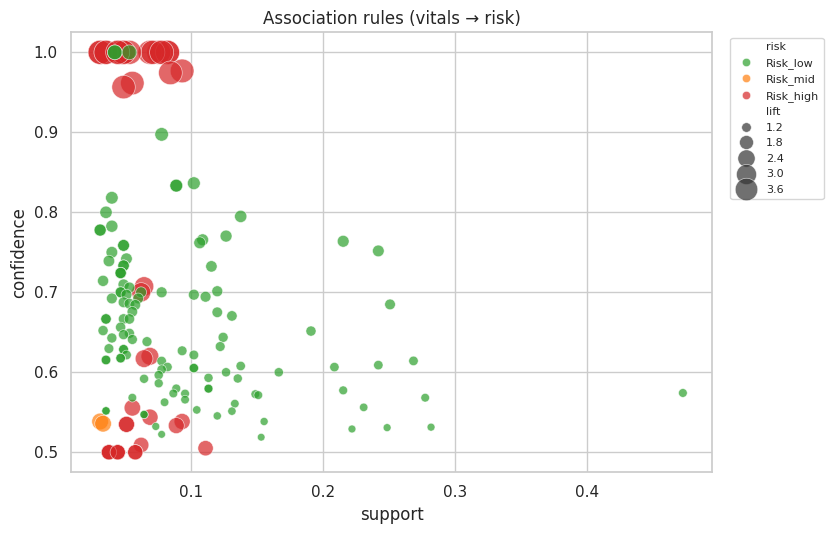

In [6]:
# Scatter: support vs confidence, hue = risk, size = lift
order = ["Risk_low", "Risk_mid", "Risk_high"]
pal = {"Risk_low": "#2ca02c", "Risk_mid": "#ff7f0e", "Risk_high": "#d62728"}
plt.figure(figsize=(8.5, 5.5))
sns.scatterplot(data=vr, x="support", y="confidence", hue="risk", size="lift",
                sizes=(30, 300), alpha=.7, hue_order=order, palette=pal)
plt.title("Association rules (vitals → risk)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.savefig(PLOTS / "16_arm_rules_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

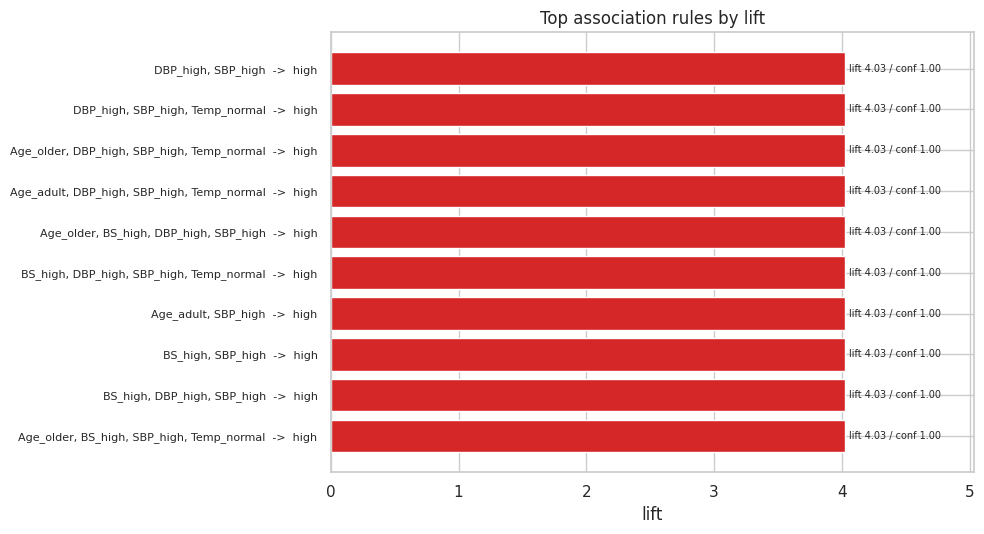

In [7]:
# Bar: top-10 rules by lift, coloured by risk
topn = vr.head(10).iloc[::-1]
labels = [f"{a}  ->  {r.split('_')[1]}" for a, r in zip(topn["antecedent"], topn["risk"])]
colors = topn["risk"].map(pal)
plt.figure(figsize=(10, 5.5))
plt.barh(range(len(topn)), topn["lift"], color=colors)
plt.yticks(range(len(topn)), labels, fontsize=8)
plt.xlabel("lift"); plt.title("Top association rules by lift")
for i, (l, cf) in enumerate(zip(topn["lift"], topn["confidence"])):
    plt.text(l + .03, i, f"lift {l:.2f} / conf {cf:.2f}", va="center", fontsize=7)
plt.xlim(0, topn["lift"].max() * 1.25)
plt.tight_layout(); plt.savefig(PLOTS / "17_arm_top_rules.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary

- Continuous vitals discretised with **guideline-based** cut-points; `HeartRate` excluded
  (no clinical-range variation).
- Apriori produced interpretable `vitals → risk` rules ranked by lift; the strongest
  high-risk rules combine **high blood sugar with high blood pressure** (lift ≈ 4),
  agreeing with the classification feature importance.
- Mid-risk produces few strong rules — it overlaps neighbouring classes, the same reason
  its classifier recall is low (a consistent cross-method finding).
- Rules saved to `data/association_rules.csv` and the discretised patient table to
  `data/maternal_discretized.csv` — both feed the rule-matching step in notebook 05 and the
  SLM narrative in notebook 06.

Next: **05_explainability**.